<center>

**<font color = "red">Project: Classification of Medical Images</font>**

---
**<font color = "green">Pneumonia Detection in Chest X-Rays using Transfer Learning</font>**

*15 April 2026*

---

*L.Chen*

*e-mail: longjie.chen@ifj.edu.pl*

---

</center>


# **Project Overview**

**Objective:** Build a CNN to classify chest X-rays as **Normal** or **Pneumonia**.

**Dataset:** Chest X-Ray Images (Pneumonia) from Kaggle  
**Model:** Custom 3-block CNN (32→64→128 filters) with dropout  
**Training:** 15 epochs, Adam optimizer, data augmentation  
**Evaluation:** Accuracy, precision, recall, confusion matrix


### **Step 1: Setup and Data Acquisition**
First, we need to set up the Kaggle API to download our dataset directly into this notebook.

**Action Required:**
1.  Create your own Kaggle API via and download your `kaggle.json` file.
2.  Run the code cell below. It will prompt you to upload the `kaggle.json`.


In [20]:
# Install Kaggle library and upload credentials
!pip install -q kaggle

from google.colab import files

print("Please upload your kaggle.json file")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\nKaggle API configured successfully!")


Please upload your kaggle.json file


Saving kaggle.json to kaggle (2).json

Kaggle API configured successfully!


Download and Unzip the Dataset

Now that the API is configured, we can download and unzip the dataset. You may need to first accept the rules of the dataset on the Kaggle website: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia).


In [33]:
# Download and unzip the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q --unzip

print("Dataset downloaded and unzipped.")
!ls chest_xray # Verify the directory structure


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Dataset downloaded and unzipped.
chest_xray  __MACOSX  test  train  val


### **Step 2: Configuration and Data Preparation**
Before we begin, we need to import the necessary Python libraries for deep learning and visualization and define the key parameters for our experiment, such as image size and batch size.

**Key paramters:**

**Image size:** 150×150 pixels (smaller for faster training)  
**Batch size:** 32 images per training step  
**Epochs:** 25 training cycles  

In [48]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Configuration

BASE_DATA_PATH = '/content/chest_xray/'
TRAIN_DIR = BASE_DATA_PATH + 'train'
VALIDATION_DIR = BASE_DATA_PATH + 'val'
TEST_DIR = BASE_DATA_PATH + 'test'

# Define model and training parameters
IMG_WIDTH, IMG_HEIGHT = 150, 150
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001

### **Step 3: Prepare Data with Augmentation**

Medical datasets are often limited. Data augmentation creates "new" training examples by applying random transformations.

**Training augmentations:**
- Rotation (±20°), shifting (±20%), zoom (±20%)
- Horizontal flipping (lungs are symmetric)
- Pixel normalization (0-255 → 0-1)

**Validation/Test:** Only normalization (no augmentation) for fair evaluation.



In [49]:
# Data Preparation and Preprocessing
print("Step 1: Preparing Data Generators...")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
validation_generator = validation_test_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
test_generator = validation_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='binary'
)
print("Found class indices:", train_generator.class_indices)

Step 1: Preparing Data Generators...
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### **Step 4: Build the CNN**
We'll construct a simple 3-block convolutional neural network from scratch.

**Structure:**
1. **Conv Block 1:** 32 filters → basic edges/textures
2. **Conv Block 2:** 64 filters → more complex patterns  
3. **Conv Block 3:** 128 filters → high-level features
4. **Classification:** Flatten → Dense(512) → Dropout(50%) → Output

In [50]:
# Model Selection and Architecture
model = Sequential([
    # First convolution block
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(2, 2),
    # Second convolution block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    # Third convolution block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    # Flatten and fully connected layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

### **Step 5: Compile and Train the Model**
**Compilation:**
- **Loss:** Binary cross-entropy (standard for 2-class problems)
- **Optimizer:** Adam with learning rate 0.001
- **Metrics:** Accuracy, precision, recall (critical for medical diagnosis)

**Training:** 25 epochs, with validation after each epoch.

**Medical context:** Recall is especially important—missing pneumonia cases (false negatives) is worse than false alarms.


In [51]:
# Compile and Train the Model
print("\nStep 3: Compiling and Training...")
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
# Train the model (ensure GPU runtime is selected)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)



Step 3: Compiling and Training...
Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 438ms/step - accuracy: 0.7531 - loss: 0.5493 - precision: 0.7781 - recall: 0.9339 - val_accuracy: 0.6250 - val_loss: 0.9709 - val_precision: 0.5714 - val_recall: 1.0000
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 434ms/step - accuracy: 0.8449 - loss: 0.3284 - precision: 0.8844 - recall: 0.9102 - val_accuracy: 0.7500 - val_loss: 0.4296 - val_precision: 0.7500 - val_recall: 0.7500
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.8710 - loss: 0.2904 - precision: 0.9114 - recall: 0.9154 - val_accuracy: 0.8125 - val_loss: 0.5963 - val_precision: 0.7778 - val_recall: 0.8750
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 442ms/step - accuracy: 0.8850 - loss: 0.2568 - precision: 0.9254 - recall: 0.9192 - val_accuracy: 0.8125 - val_loss: 0.4546 - val_precision: 0.8571 - val_recall: 0.7500
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 431ms/step - accuracy: 0.8884 - loss: 0.2521 - precision: 0.9296 - re

### **Step 6: Evaluate on Test Data**
Now we test our trained model on completely unseen images.

**Metrics we'll examine:**
1. **Overall accuracy:** Percentage of correct predictions
2. **Precision:** Of predicted pneumonia cases, how many actually have pneumonia?
3. **Recall:** Of actual pneumonia cases, how many did we detect?
4. **Confusion matrix:** Visual breakdown of true/false predictions



Step 4: Evaluating the Model on the Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.8205 - loss: 0.5284 - precision: 0.7837 - recall: 0.9846

Test Accuracy: 82.05%
Test Precision: 78.37%
Test Recall: 98.46%
Test Loss: 0.5284
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step


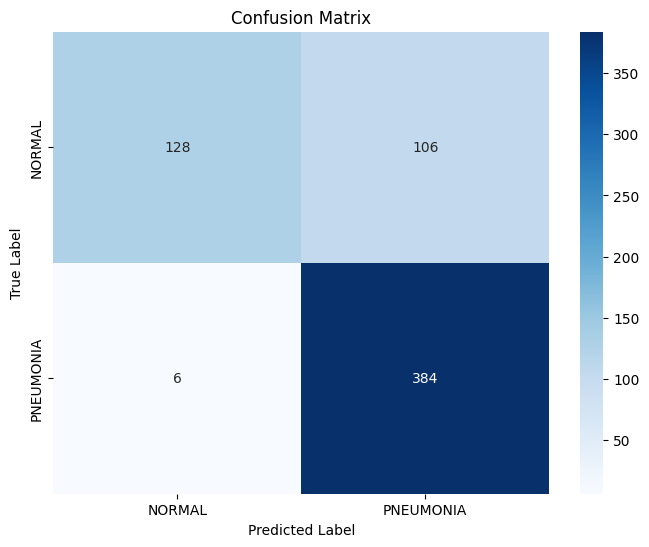


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.55      0.70       234
   PNEUMONIA       0.78      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.77      0.78       624
weighted avg       0.85      0.82      0.81       624



In [52]:
# Evaluation
print("\nStep 4: Evaluating the Model on the Test Set...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Precision: {test_precision*100:.2f}%")
print(f"Test Recall: {test_recall*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
# Predict classes
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

### **Step 7: Analyze Training History**
Let's plot the training and validation metrics to diagnose model behavior.

**What to look for:**
- **Good fit:** Training and validation curves converge
- **Overfitting:** Training accuracy keeps rising while validation plateaus
- **Underfitting:** Both curves plateau at low accuracy


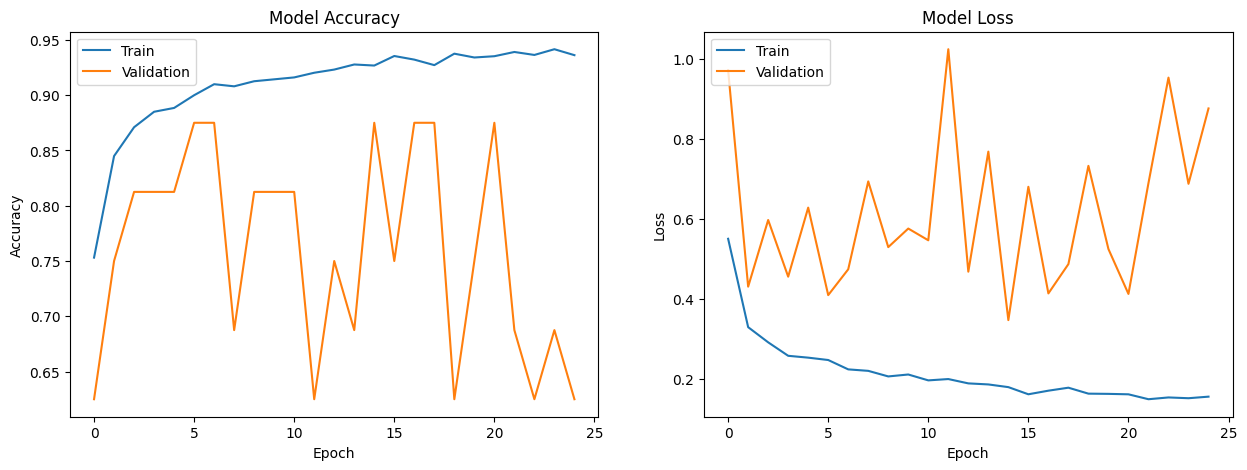

In [53]:
# Plot Training History
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    plt.show()
plot_history(history)

### **Step 8: Visualize Sample Predictions**
Seeing actual X-rays with model predictions helps build intuition.
**Display:** 8 test images with:
- True label (Normal/Pneumonia)
- Predicted label  
- Green title = correct, Red title = incorrect

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


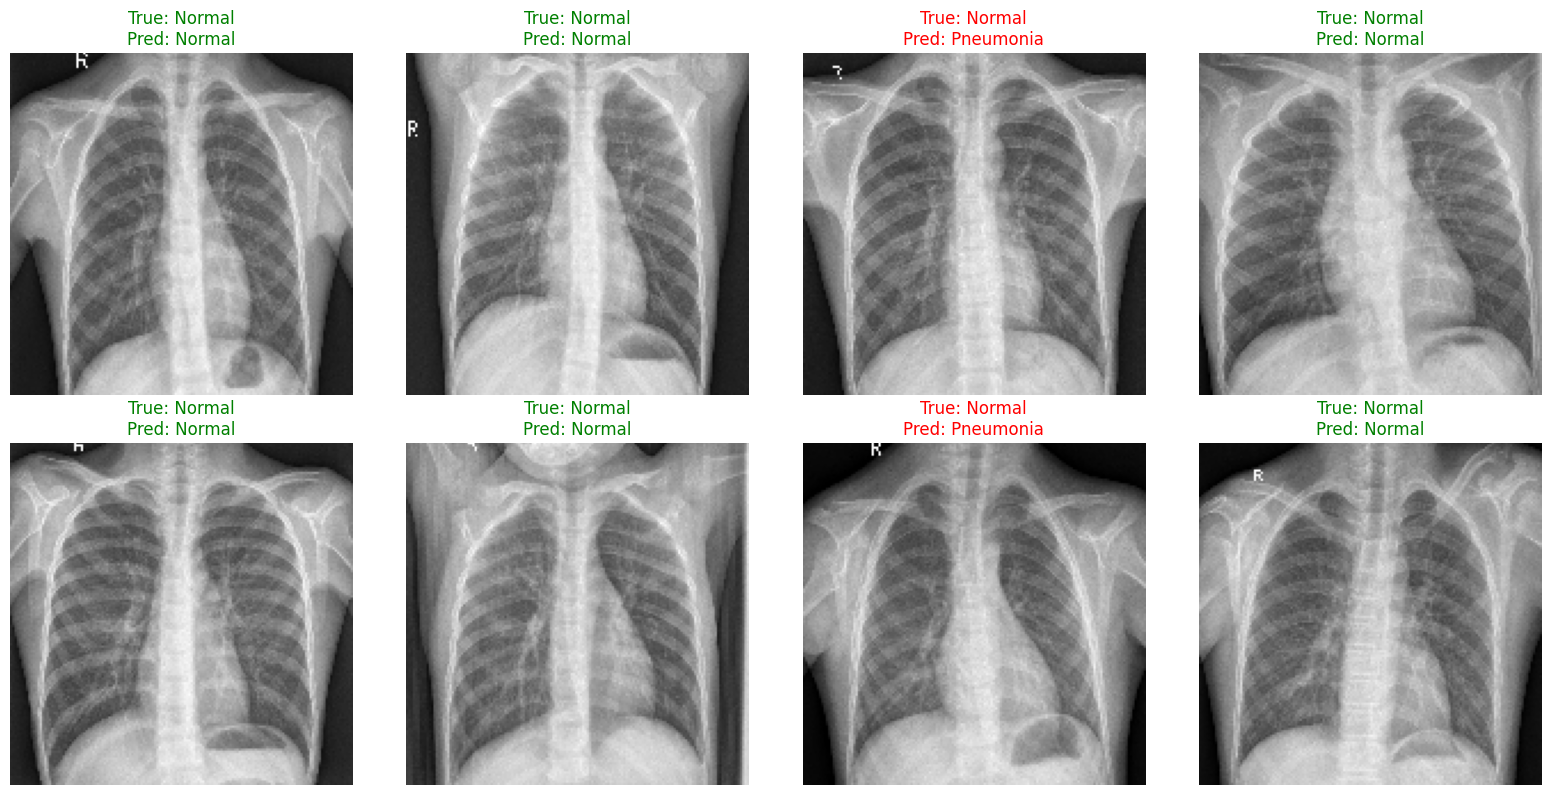

In [54]:
# Display a few test images with their predicted labels
def show_sample_predictions(generator, model, num_samples=8):
    x_batch, y_batch = next(generator)
    preds = model.predict(x_batch)
    pred_labels = (preds > 0.5).astype(int).flatten()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for i in range(num_samples):
        axes[i].imshow(x_batch[i])
        true_label = 'Pneumonia' if y_batch[i] == 1 else 'Normal'
        pred_label = 'Pneumonia' if pred_labels[i] == 1 else 'Normal'
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
# Reset test generator to get a fresh batch
test_generator.reset()
show_sample_predictions(test_generator, model, num_samples=8)